In [14]:
from pathlib import Path

import mglyph as mg
import math

export_dir = Path("bp-typst/img/glyphs")

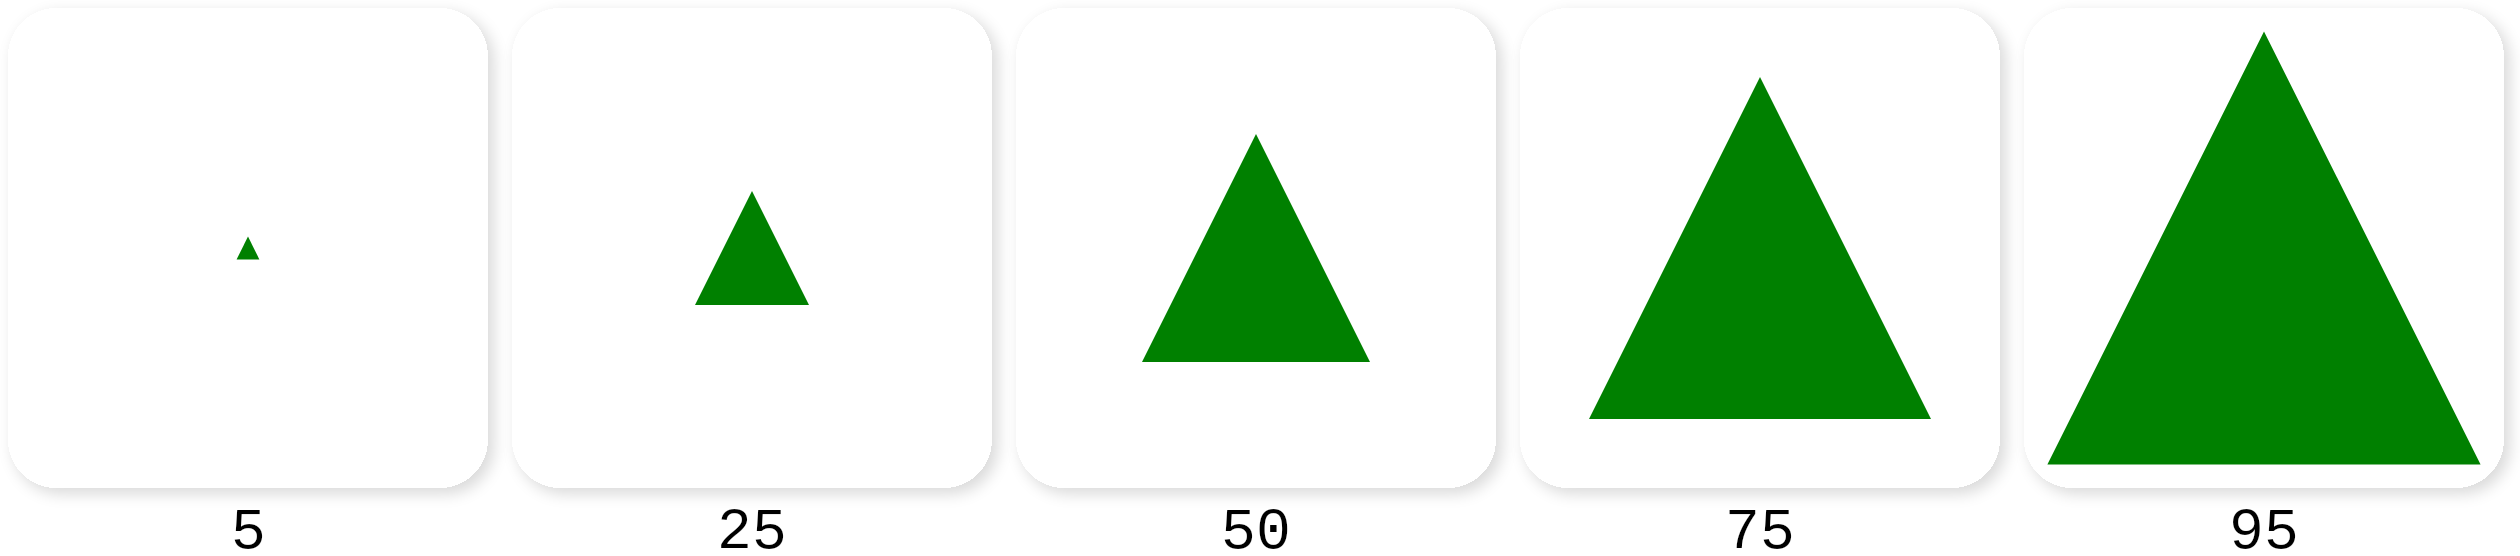

In [29]:
# Green Triangle

def triangle(x: float, canvas: mg.Canvas):
    canvas.tr.scale(x / 100.0)
    canvas.polygon([canvas.bottom_left, canvas.bottom_right, canvas.top_center], color='green')

mg.show(triangle, scale=5)

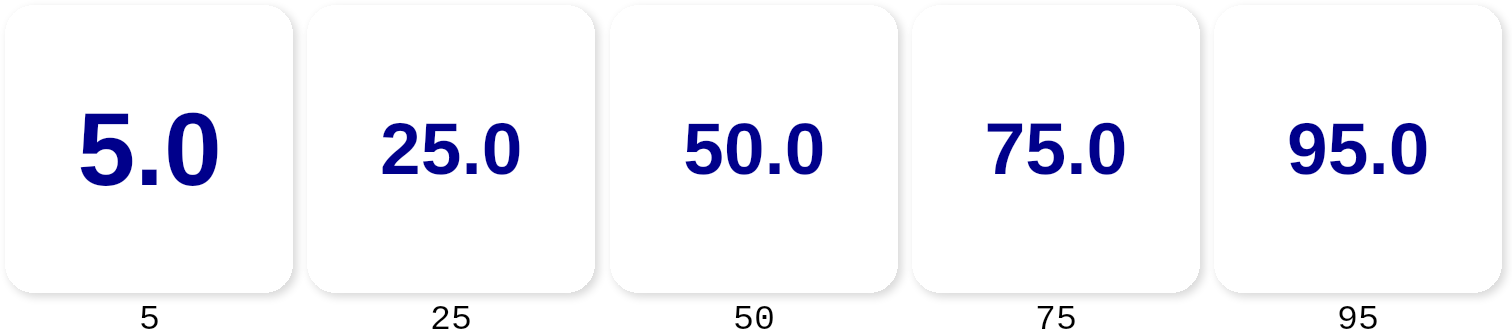

In [19]:
def text_value_glyph(x: float, canvas: mg.Canvas) -> None:  
    # Display the value of x as text in the center  
    text_value = f"{x:.1f}"  
    canvas.text(text_value,   
                position=canvas.center,  
                font='Arial',  
                size=1,  # Large enough to be readable  
                anchor='center',  
                color='darkblue',  
                font_weight='bold')


  
# Show the glyph  
mg.show(text_value_glyph, scale=3) 

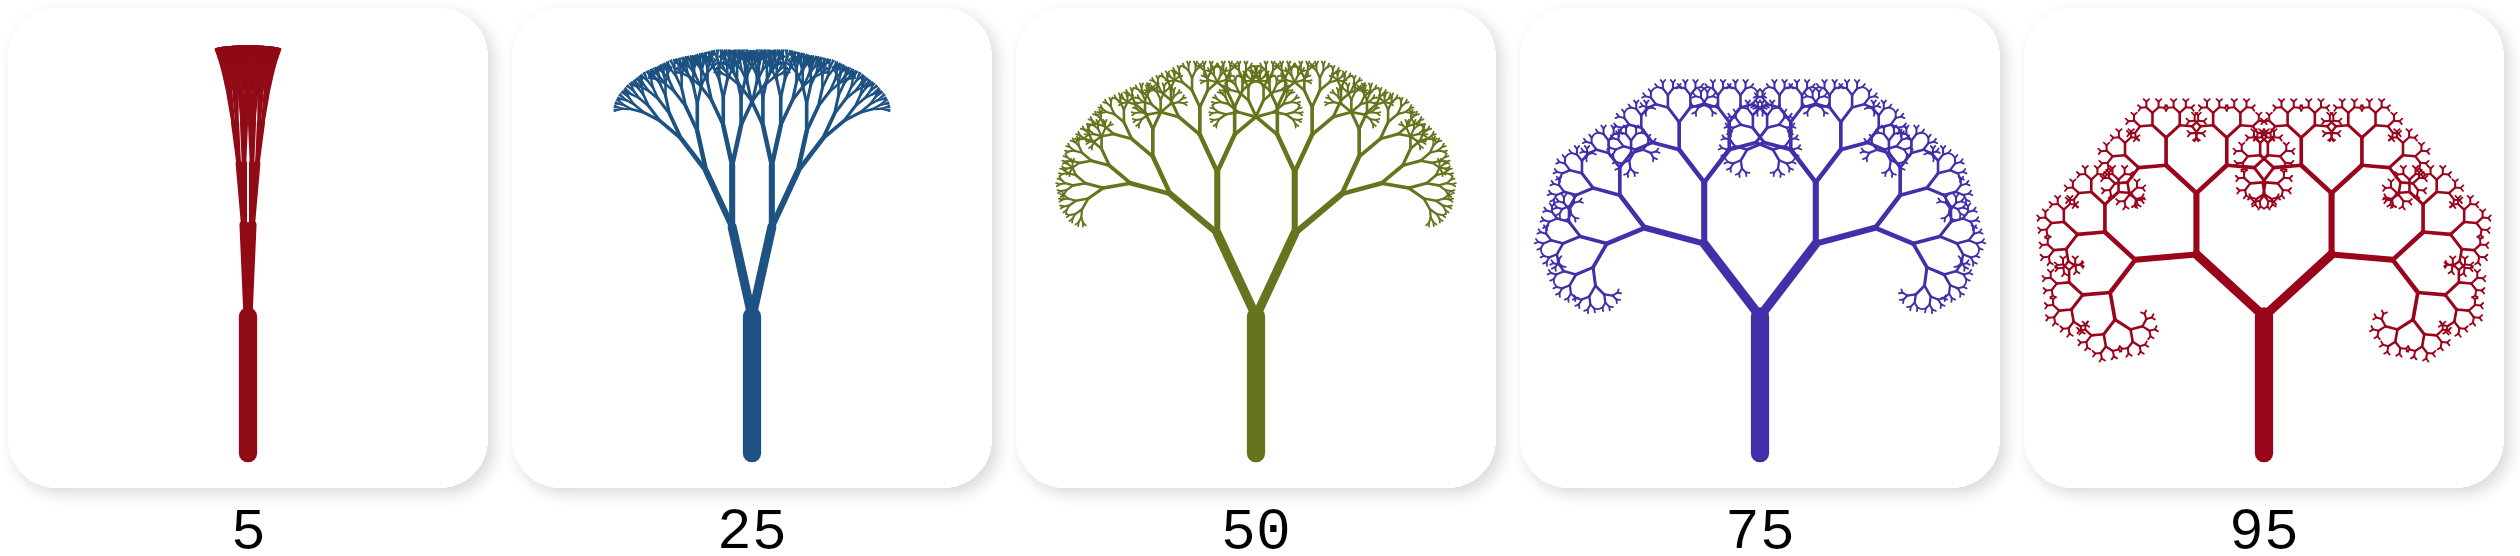

In [28]:
map = mg.ColorMap(map="dark")


def fractal_tree(x: float, canvas: mg.Canvas) -> None:
    color = map.get_color(x)
    angle = x * 0.5

    def branch(length: float, depth: int):
        canvas.line(
            (0, 0),
            (0, -length),
            width=canvas.xsize * 0.05 / depth,
            linecap="round",
            color=color,
        )
        canvas.tr.translate(0, -length)
        if depth < 10:
            canvas.tr.push()
            canvas.tr.rotate(angle)
            branch(length * 0.67, depth + 1)
            canvas.tr.pop()
            canvas.tr.push()
            canvas.tr.rotate(-angle)
            branch(length * 0.67, depth + 1)
            canvas.tr.pop()

    canvas.tr.translate(canvas.xcenter, canvas.ybottom)
    canvas.tr.translate(0, -0.05 * canvas.ysize)
    canvas.tr.scale(0.8)
    branch(0.75, 1)


mg.show(fractal_tree, scale=5)